In [1]:
from itu.algs4.graphs.digraph import *
import matplotlib.pyplot as plt
import numpy as np

### 1. Leitura do arquivo

In [2]:
global G

with open("files/web-Stanford.txt", "r") as f:
    first_line = f.readline().strip().split()
    V = int(first_line[0])
    E = int(first_line[1])

    G = Digraph(V, first_index=1)

    for line in f:
        v, w = map(int, line.strip().split())
        G.add_edge(v, w)

with open("files/in_degree_list.txt", 'w') as f:
    f.write(G.in_degree_list())

with open("files/out_degree_list.txt", 'w') as f:
    f.write(G.out_degree_list())

with open("files/degree_list.txt", 'w') as f:
    f.write(G.degree_list())

print(f"Número de vértices: {G.V()}")
print(f"Número de arestas: {G.E()}")

Número de vértices: 281903
Número de arestas: 2312497


### 2. Densidade

In [3]:
density = G.density()
print(f"Densidade: {density:.9f}")

Densidade: 0.000029099


### 3. Distribuição de graus

In [ ]:
global in_degrees, out_degrees, degrees

with open("files/in_degree_list.txt", 'r') as f:
    in_degrees = [int(line.strip().split(": ")[1]) for line in f.readlines()[1:]] 

with open("files/out_degree_list.txt", 'r') as f:
    out_degrees = [int(line.strip().split(": ")[1]) for line in f.readlines()[1:]]

with open("files/degree_list.txt", 'r') as f:
    degrees = [int(line.strip().split(": ")[1]) for line in f.readlines()[1:]]

In [46]:
max_in_degree = max(in_degrees)
max_out_degree = max(out_degrees)

min_in_degree = min(in_degrees)
min_out_degree = min(out_degrees)

max_degree = max(degrees)
min_degree = min(degrees)

avg_in_degree = sum(in_degrees) / len(in_degrees)
avg_out_degree = sum(out_degrees) / len(out_degrees)
# avg_degree = sum(degrees) / len(degrees)

print(f"max in degree: {max_in_degree}\nmin in degree: {min_in_degree}")
print(f"avg in degree: {avg_in_degree:.2f}")
print("="*20)
print(f"max out degree: {max_out_degree}\nmin out degree: {min_out_degree}")
print(f"avg out degree: {avg_out_degree:.2f}")
print("="*20)
# print(f"max degree: {max_degree}\nmin degree: {min_degree}")
# print(f"avg degree: {avg_degree:.2f}")
# variancia de in degree usindo numpy
in_degree_variance = np.var(in_degrees)
out_degree_variance = np.var(out_degrees)
# degree_variance = np.var(degrees)
print(f"variância in degree: {in_degree_variance:.2f}")
print(f"variância out degree: {out_degree_variance:.2f}")

max in degree: 38606
min in degree: 0
avg in degree: 8.20
max out degree: 255
min out degree: 0
avg out degree: 8.20
variância in degree: 27666.22
variância out degree: 127.95


### 4. Plot distribuição de graus (Histograma)

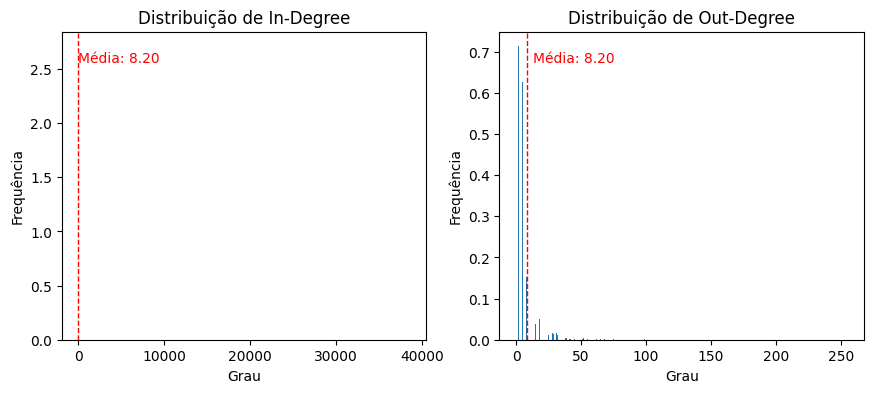

In [53]:
plt.figure(figsize=(16,4))

plt.subplot(1,3,1)
plt.hist(in_degrees, bins="fd", density=True)
plt.title("Distribuição de In-Degree")
plt.xlabel("Grau")
plt.ylabel("Frequência")
plt.axvline(avg_in_degree, color='red', linestyle='dashed', linewidth=1)
plt.text(avg_in_degree + 5, plt.ylim()[1]*0.9, f'Média: {avg_in_degree:.2f}', color='red')

plt.subplot(1,3,2)
plt.hist(out_degrees, bins="fd", density=True)
plt.title("Distribuição de Out-Degree")
plt.xlabel("Grau")
plt.ylabel("Frequência")
plt.axvline(avg_out_degree, color='red', linestyle='dashed', linewidth=1)
plt.text(avg_out_degree + 5, plt.ylim()[1]*0.9, f'Média: {avg_out_degree:.2f}', color='red')

# plt.subplot(1,3,3)
# plt.hist(degrees, bins="fd", density=True)
# plt.title("Distribuição de Degree")
# plt.xlabel("Grau")
# plt.ylabel("Frequência")
# plt.axvline(avg_degree, color='red', linestyle='dashed', linewidth=1)
# plt.text(avg_degree + 5, plt.ylim()[1]*0.9, f'Média: {avg_degree:.2f}', color='red')

plt.show()

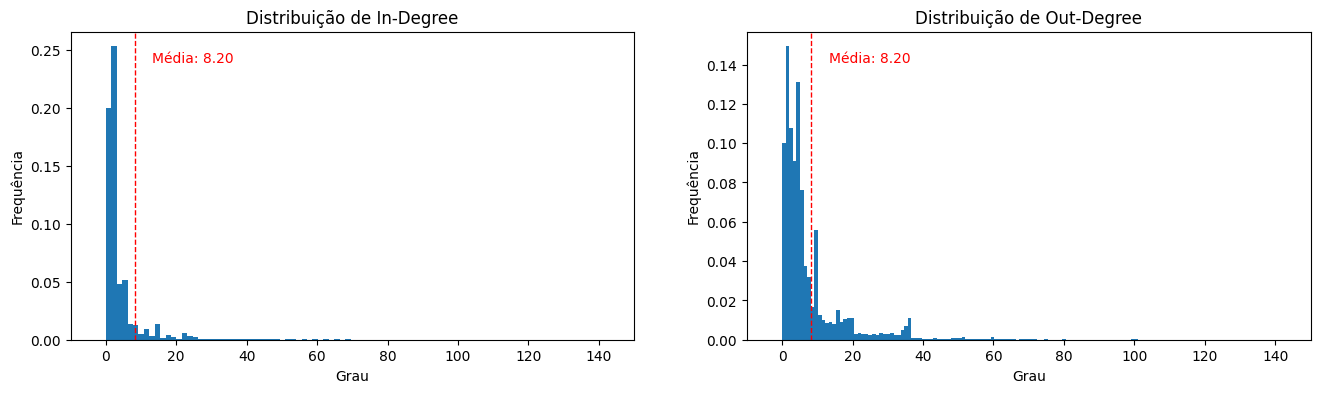

In [65]:
plt.figure(figsize=(16,4))

plt.subplot(1,2,1)
plt.hist(in_degrees, bins=25000, density=True)
plt.xlim(-10, 150)
plt.title("Distribuição de In-Degree")
plt.xlabel("Grau")
plt.ylabel("Frequência")
plt.axvline(avg_in_degree, color='red', linestyle='dashed', linewidth=1)
plt.text(avg_in_degree + 5, plt.ylim()[1]*0.9, f'Média: {avg_in_degree:.2f}', color='red')

plt.subplot(1,2,2)
plt.hist(out_degrees, bins=250, density=True)
plt.xlim(-10, 150)
plt.title("Distribuição de Out-Degree")
plt.xlabel("Grau")
plt.ylabel("Frequência")
plt.axvline(avg_out_degree, color='red', linestyle='dashed', linewidth=1)
plt.text(avg_out_degree + 5, plt.ylim()[1]*0.9, f'Média: {avg_out_degree:.2f}', color='red')

# plt.subplot(1,3,3)
# plt.hist(degrees, bins=20000, density=True)
# plt.xlim(-10, min([1.1*max(in_degrees), 1.1*max(out_degrees), 1.1*max(degrees)]))
# plt.title("Distribuição de Degree")
# plt.xlabel("Grau")
# plt.ylabel("Frequência")
# plt.axvline(avg_degree, color='red', linestyle='dashed', linewidth=1)
# plt.text(avg_degree + 5, plt.ylim()[1]*0.9, f'Média: {avg_degree:.2f}', color='red')

plt.show()

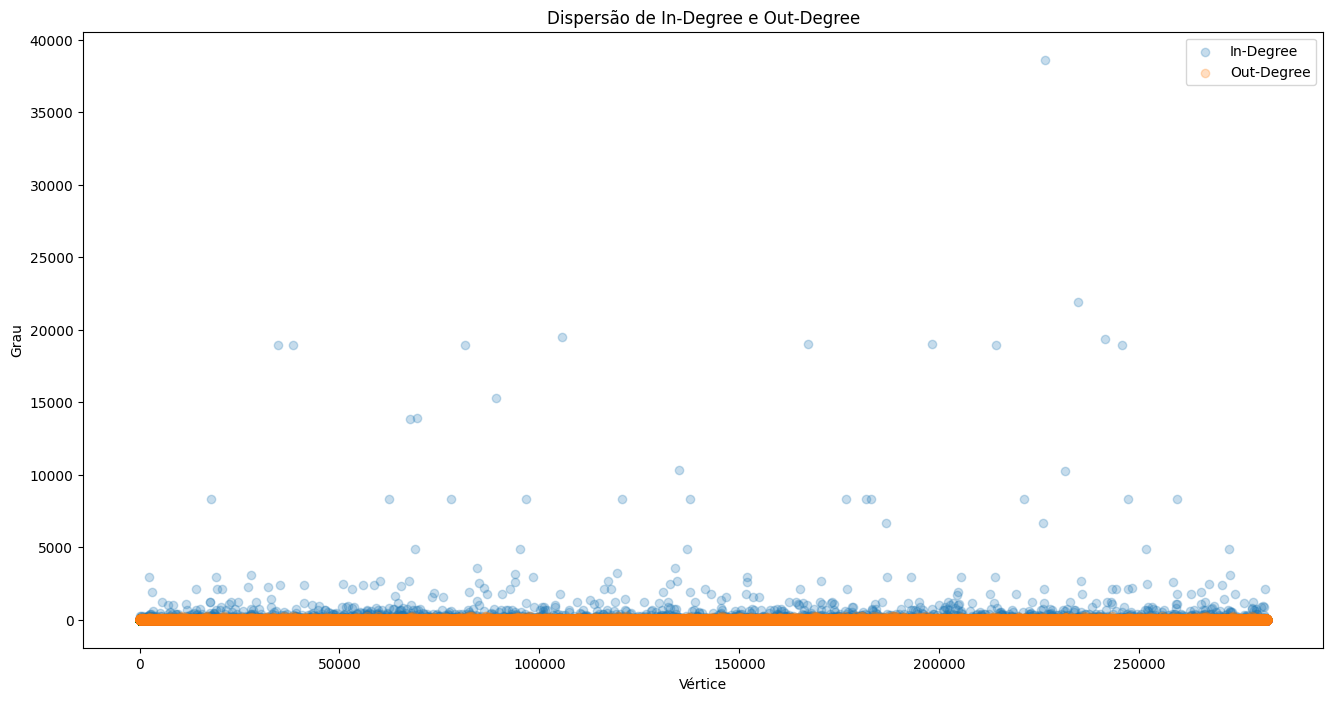

In [51]:
# plotar dispersão de graus
plt.figure(figsize=(16,8))

plt.scatter(range(len(in_degrees)), in_degrees, alpha=0.25, label="In-Degree")
plt.scatter(range(len(out_degrees)), out_degrees, alpha=0.25, label="Out-Degree")
plt.title("Dispersão de In-Degree e Out-Degree")
plt.xlabel("Vértice")
plt.ylabel("Grau")
plt.legend()

plt.show()

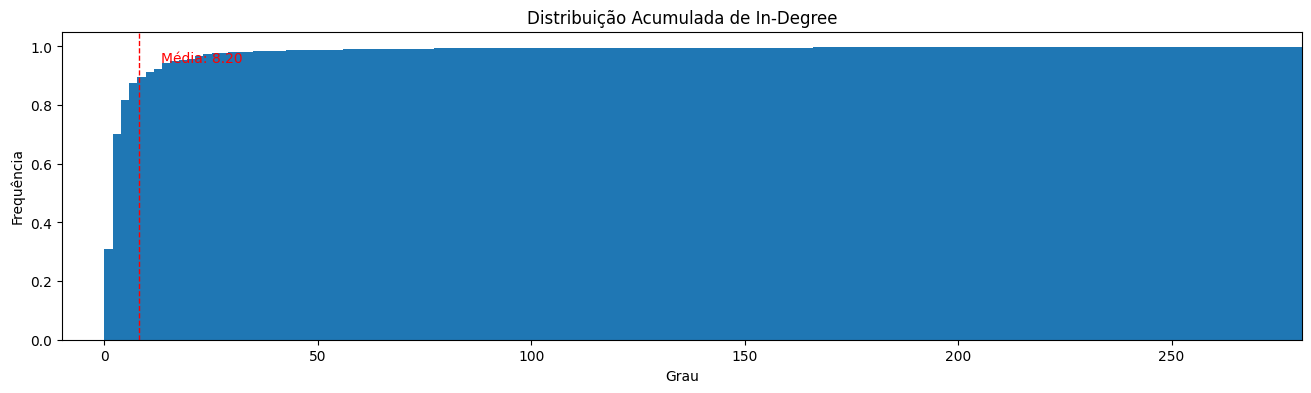

In [ ]:
# distribuição acumulada de in degree
plt.figure(figsize=(16,4))
plt.hist(in_degrees, bins=20000, density=True, cumulative=True)
plt.xlim(-10, min([1.1*max(in_degrees), 1.1*max(out_degrees), 1.1*max(degrees)]))
plt.title("Distribuição Acumulada de In-Degree")
plt.xlabel("Grau")
plt.ylabel("Frequência")
plt.axvline(avg_in_degree, color='red', linestyle='dashed', linewidth=1)
plt.text(avg_in_degree + 5, plt.ylim()[1]*0.9, f'Média: {avg_in_degree:.2f}', color='red')
plt.show()

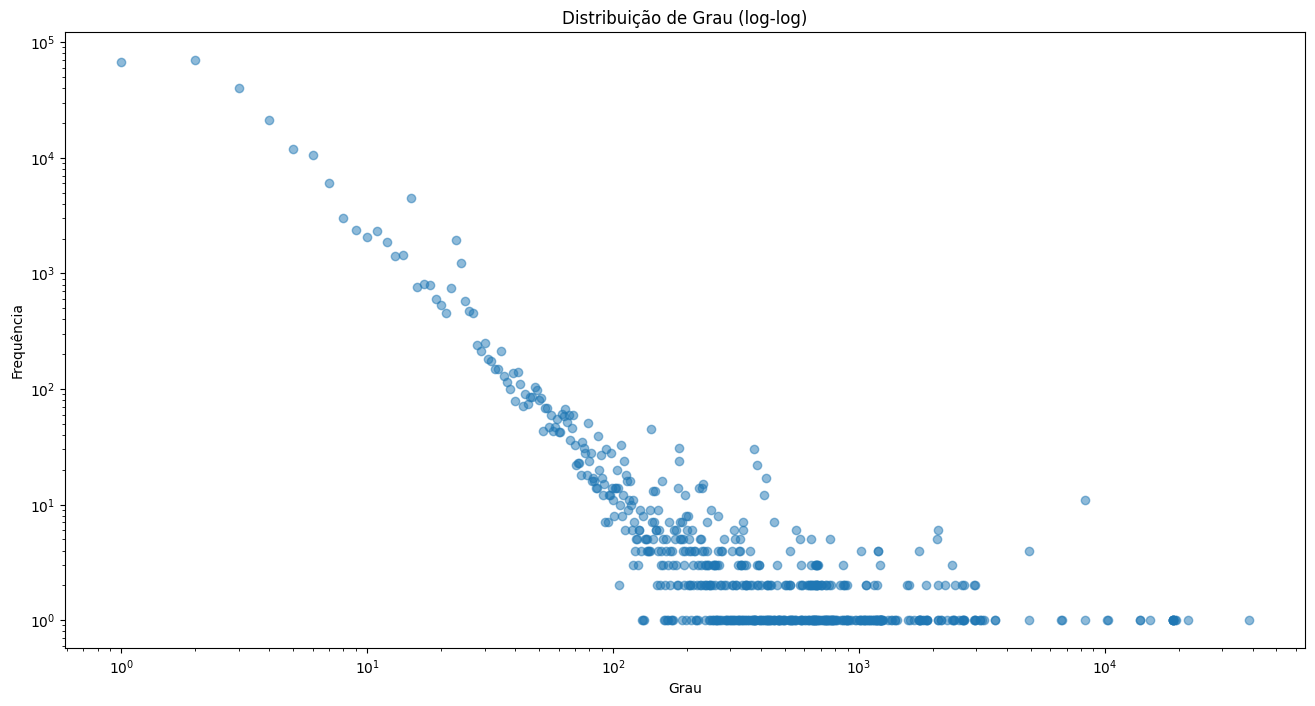

In [62]:
# Frequência acumulada
degree_count = np.bincount(in_degrees) # freq de cada grau
degrees = np.arange(len(degree_count)) # array de graus correspondente aos índices do degree_count

plt.figure(figsize=(16,8))
plt.loglog(degrees[degree_count > 0], degree_count[degree_count > 0], marker="o", linestyle="None", alpha=0.5)
plt.title("Distribuição de Grau (log-log)")
plt.xlabel("Grau")
plt.ylabel("Frequência")
plt.show()